Aliyah Sabir

#Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV


#Load data

In [4]:
df = pd.read_csv('/content/Collin_CAD_Appraisal_Data_-_2024_20250717.csv')

/tmp/ipython-input-4-1122112803.py:1: DtypeWarning: Columns (29,30,31,32,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Collin_CAD_Appraisal_Data_-_2024_20250717.csv')


#EDA

In [ ]:
df.shape

(454906, 102)

In [ ]:
df.describe()

,propYear,propID,udiGroupID,udiInterestPct,commonInterestPct,ecoGroupID,ecoGroupGBA,ecoGroupNRA,propSplitFromPID,situsZip,...,prevValAssessed,noticeYear,noticeValImprv,noticeValLand,noticeValMarket,noticeValAgLoss,noticeValAppraised,noticeValHSCapLoss,noticeValNHSCapLoss,noticeValAssessed
count,454906.0,4.549060e+05,7.743000e+03,7743.000000,4185.000000,6798.000000,6.798000e+03,6.798000e+03,1.776700e+04,441225.000000,...,4.266330e+05,432927.0,4.329270e+05,4.329270e+05,4.329270e+05,4.329270e+05,4.329270e+05,4.329270e+05,4.329270e+05,4.329270e+05
mean,2024.0,2.194101e+06,2.828803e+06,49.393000,5.538154,40177.376434,7.936490e+04,7.387837e+04,1.883694e+06,75116.693070,...,6.016872e+05,2024.0,4.605677e+05,2.033565e+05,6.996102e+05,-3.004612e+04,6.695641e+05,3.506855e+04,1.646169e+03,6.328552e+05
std,0.0,8.007209e+05,8.971424e+04,8.477654,8.983089,16000.199062,1.614427e+05,1.441215e+05,7.654461e+05,183.383802,...,4.340701e+06,0.0,3.367860e+06,8.522257e+05,4.675622e+06,5.295704e+05,4.648127e+06,6.365627e+04,2.743077e+04,4.647014e+06
min,2024.0,3.700000e+01,2.569358e+06,0.000000,0.010400,35.000000,0.000000e+00,0.000000e+00,7.960000e+02,5442.000000,...,0.000000e+00,2024.0,0.000000e+00,0.000000e+00,1.000000e+00,-8.597249e+07,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2024.0,2.006010e+06,2.782088e+06,50.000000,0.943300,28325.500000,5.000000e+03,5.000000e+03,1.139743e+06,75034.000000,...,2.319000e+05,2024.0,1.670225e+05,8.800000e+04,2.958330e+05,0.000000e+00,2.822750e+05,0.000000e+00,0.000000e+00,2.671535e+05
50%,2024.0,2.564184e+06,2.849431e+06,50.000000,2.360000,49008.000000,1.486900e+04,1.482100e+04,2.118155e+06,75071.000000,...,3.889610e+05,2024.0,3.245490e+05,1.200000e+05,4.571210e+05,0.000000e+00,4.502170e+05,0.000000e+00,0.000000e+00,4.217600e+05
75%,2024.0,2.765728e+06,2.896681e+06,50.000000,6.250000,52771.250000,8.440275e+04,8.159800e+04,2.590314e+06,75098.000000,...,5.325340e+05,2024.0,4.637690e+05,1.653000e+05,6.444530e+05,0.000000e+00,6.333160e+05,5.505000e+04,0.000000e+00,5.793015e+05
max,2024.0,2.947144e+06,2.941618e+06,99.990000,99.710000,55083.000000,1.963751e+06,1.830233e+06,2.935685e+06,75962.000000,...,8.522724e+08,2024.0,8.502338e+08,8.824127e+07,1.393579e+09,0.000000e+00,1.393579e+09,1.628461e+06,2.521442e+06,1.393579e+09


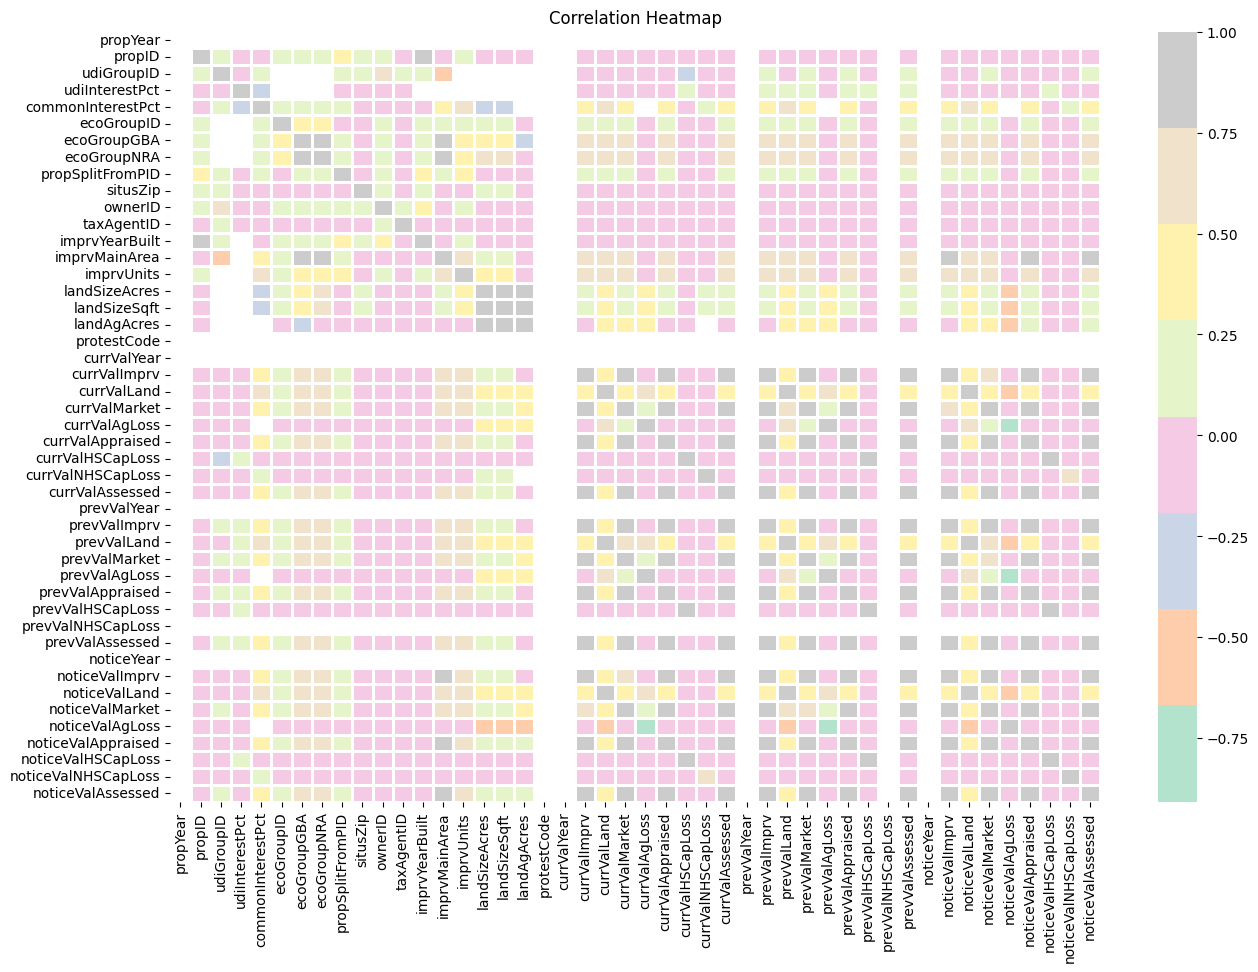

In [ ]:
# keep only numeric columns
numeric_df = df.select_dtypes(include='number')

# Plot heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), annot=False, fmt='.2f', cmap='Pastel2', linewidths=2)
plt.title('Correlation Heatmap')
plt.show()

#Data cleaning and wrangling

In [5]:
df.columns.tolist()

['propYear',
 'propID',
 'geoID',
 'propType',
 'propSubType',
 'propCategoryCode',
 'propUseCode',
 'mapID',
 'nbhdCode',
 'marketAreaCode',
 'legalAbsSubCode',
 'legalAbsSubName',
 'legalAbsSubBlock',
 'legalAbsSubLot',
 'legalDescription',
 'dbaName',
 'comPropFlag',
 'udiPropFlag',
 'udiGroupID',
 'udiInterestPct',
 'commonInterestPct',
 'ecoGroupID',
 'ecoGroupGBA',
 'ecoGroupNRA',
 'propSplitFromPID',
 'propCreateDate',
 'entityCodes',
 'entitySchoolCode',
 'entityCityCode',
 'entityMUD',
 'entityTIF',
 'entitySBCL',
 'situsBldgNum',
 'situsStreetPrefix',
 'situsStreetName',
 'situsStreetSuffix',
 'situsUnit',
 'situsCity',
 'situsZip',
 'situsConcat',
 'situsConcatShort',
 'ownerID',
 'ownerName',
 'ownerNameAddtl',
 'ownerAddrLine1',
 'ownerAddrLine2',
 'ownerAddrCity',
 'ownerAddrState',
 'ownerAddrZip',
 'ownerAddrCountry',
 'taxAgentID',
 'taxAgentName',
 'deedTypeCd',
 'deedNum',
 'deedBook',
 'deedPage',
 'deedEffDate',
 'deedFileDate',
 'imprvYearBuilt',
 'imprvClassCd',


In [6]:
print(df.isnull().sum())

propYear                   0
propID                     0
geoID                      0
propType                   0
propSubType                0
                       ...  
noticeValHSCapLoss     21979
noticeValNHSCapLoss    21979
noticeValAssessed      21979
noticeDate             21979
dataDate                   0
Length: 102, dtype: int64


In [7]:
# Count null values per column
null_counts = df.isnull().sum()

# Filter for columns with at least one null value
null_columns = null_counts[null_counts > 0].index.tolist()

print("Columns with null values:")
for col in null_columns:
    print(f"- {col} (Nulls: {null_counts[col]})")

Columns with null values:
- propCategoryCode (Nulls: 391)
- propUseCode (Nulls: 438686)
- mapID (Nulls: 22712)
- nbhdCode (Nulls: 48130)
- marketAreaCode (Nulls: 436275)
- legalAbsSubCode (Nulls: 35414)
- legalAbsSubName (Nulls: 38993)
- legalAbsSubBlock (Nulls: 75924)
- legalAbsSubLot (Nulls: 39290)
- legalDescription (Nulls: 911)
- dbaName (Nulls: 404124)
- udiGroupID (Nulls: 447163)
- udiInterestPct (Nulls: 447163)
- commonInterestPct (Nulls: 450721)
- ecoGroupID (Nulls: 448108)
- ecoGroupGBA (Nulls: 448108)
- ecoGroupNRA (Nulls: 448108)
- propSplitFromPID (Nulls: 437139)
- propCreateDate (Nulls: 60536)
- entityCodes (Nulls: 3)
- entitySchoolCode (Nulls: 6257)
- entityCityCode (Nulls: 59689)
- entityMUD (Nulls: 3)
- entityTIF (Nulls: 3)
- entitySBCL (Nulls: 3)
- situsBldgNum (Nulls: 41817)
- situsStreetPrefix (Nulls: 426586)
- situsStreetName (Nulls: 11879)
- situsStreetSuffix (Nulls: 45901)
- situsUnit (Nulls: 428818)
- situsCity (Nulls: 12822)
- situsZip (Nulls: 13681)
- situsConc

##Median imputation

In [8]:
# median imputation
df['prevValMarket'].fillna(df['prevValMarket'].median(), inplace=True)
df['noticeValMarket'].fillna(df['noticeValMarket'].median(), inplace=True)


/tmp/ipython-input-8-4137457719.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['prevValMarket'].fillna(df['prevValMarket'].median(), inplace=True)
/tmp/ipython-input-8-4137457719.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [9]:
# Count null values per column
null_counts = df.isnull().sum()

# Filter for columns with at least one null value
null_columns = null_counts[null_counts > 0].index.tolist()

print("Columns with null values:")
for col in null_columns:
    print(f"- {col} (Nulls: {null_counts[col]})")

Columns with null values:
- propCategoryCode (Nulls: 391)
- propUseCode (Nulls: 438686)
- mapID (Nulls: 22712)
- nbhdCode (Nulls: 48130)
- marketAreaCode (Nulls: 436275)
- legalAbsSubCode (Nulls: 35414)
- legalAbsSubName (Nulls: 38993)
- legalAbsSubBlock (Nulls: 75924)
- legalAbsSubLot (Nulls: 39290)
- legalDescription (Nulls: 911)
- dbaName (Nulls: 404124)
- udiGroupID (Nulls: 447163)
- udiInterestPct (Nulls: 447163)
- commonInterestPct (Nulls: 450721)
- ecoGroupID (Nulls: 448108)
- ecoGroupGBA (Nulls: 448108)
- ecoGroupNRA (Nulls: 448108)
- propSplitFromPID (Nulls: 437139)
- propCreateDate (Nulls: 60536)
- entityCodes (Nulls: 3)
- entitySchoolCode (Nulls: 6257)
- entityCityCode (Nulls: 59689)
- entityMUD (Nulls: 3)
- entityTIF (Nulls: 3)
- entitySBCL (Nulls: 3)
- situsBldgNum (Nulls: 41817)
- situsStreetPrefix (Nulls: 426586)
- situsStreetName (Nulls: 11879)
- situsStreetSuffix (Nulls: 45901)
- situsUnit (Nulls: 428818)
- situsCity (Nulls: 12822)
- situsZip (Nulls: 13681)
- situsConc

In [10]:
# verify that noticeValMarket and preValMarket have 0 null values

print((df[df['noticeValMarket'].isnull()]))
print((df[df['prevValMarket'].isnull()]))

Empty DataFrame
Columns: [propYear, propID, geoID, propType, propSubType, propCategoryCode, propUseCode, mapID, nbhdCode, marketAreaCode, legalAbsSubCode, legalAbsSubName, legalAbsSubBlock, legalAbsSubLot, legalDescription, dbaName, comPropFlag, udiPropFlag, udiGroupID, udiInterestPct, commonInterestPct, ecoGroupID, ecoGroupGBA, ecoGroupNRA, propSplitFromPID, propCreateDate, entityCodes, entitySchoolCode, entityCityCode, entityMUD, entityTIF, entitySBCL, situsBldgNum, situsStreetPrefix, situsStreetName, situsStreetSuffix, situsUnit, situsCity, situsZip, situsConcat, situsConcatShort, ownerID, ownerName, ownerNameAddtl, ownerAddrLine1, ownerAddrLine2, ownerAddrCity, ownerAddrState, ownerAddrZip, ownerAddrCountry, taxAgentID, taxAgentName, deedTypeCd, deedNum, deedBook, deedPage, deedEffDate, deedFileDate, imprvYearBuilt, imprvClassCd, imprvMainArea, imprvUnits, imprvPoolFlag, imprvCategoryCodes, landTypeCode, landSizeAcres, landSizeSqft, landAgAcres, landCategoryCodes, exemptCodes, exem

In [11]:
df.drop([])

,propYear,propID,geoID,propType,propSubType,propCategoryCode,propUseCode,mapID,nbhdCode,marketAreaCode,...,noticeValImprv,noticeValLand,noticeValMarket,noticeValAgLoss,noticeValAppraised,noticeValHSCapLoss,noticeValNHSCapLoss,noticeValAssessed,noticeDate,dataDate
0,2024,37,R-0002-00A-0030-1,Real,Commercial,F1,MDO,112.T,NaN,PW,...,1862032.0,640406.0,2502438.0,0.0,2502438.0,0.0,342438.0,2160000.0,04/15/2024,2025-07-14T00:29:32.693
1,2024,46,R-0003-00A-0010-1,Real,Commercial,F1,OCCLR1-3,129.A,CORP,PW,...,22841076.0,36476360.0,59317436.0,0.0,59317436.0,0.0,0.0,59317436.0,04/15/2024,2025-07-14T00:29:32.693
2,2024,55,R-0005-001-0010-1,Real,Land,C1,NaN,110.T,S0005,NaN,...,0.0,150000.0,150000.0,0.0,150000.0,0.0,84000.0,66000.0,04/15/2024,2025-07-14T00:29:32.693
3,2024,64,R-0005-001-0020-1,Real,Land,C1,NaN,110.U,S0005,NaN,...,0.0,150000.0,150000.0,0.0,150000.0,0.0,84000.0,66000.0,04/15/2024,2025-07-14T00:29:32.693
4,2024,73,R-0005-001-0030-1,Real,Land,C1,NaN,110.U,S0005,NaN,...,0.0,150000.0,150000.0,0.0,150000.0,0.0,84000.0,66000.0,04/15/2024,2025-07-14T00:29:32.693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454901,2024,2008327,R-2919-00A-0090-1,Real,Residential,A,NaN,047.M,N0804,NaN,...,629431.0,152190.0,781621.0,0.0,781621.0,172555.0,0.0,609066.0,04/15/2024,2025-07-14T00:29:32.693
454902,2024,2008328,R-2919-00A-0100-1,Real,Residential,A,NaN,047.M,N0804,NaN,...,661775.0,152204.0,813979.0,0.0,813979.0,57729.0,0.0,756250.0,04/15/2024,2025-07-14T00:29:32.693
454903,2024,2008329,R-2919-00A-0110-1,Real,Residential,A,NaN,048.E,N0804,NaN,...,650535.0,153159.0,803694.0,0.0,803694.0,198089.0,0.0,605605.0,04/15/2024,2025-07-14T00:29:32.693
454904,2024,2008332,R-2919-00A-0140-1,Real,Residential,A,NaN,048.J,N0804,NaN,...,797103.0,405915.0,1203018.0,0.0,1203018.0,133400.0,0.0,1069618.0,04/15/2024,2025-07-14T00:29:32.693


#Research questions

##RQ 1: What are the highest and lowest valued property types?

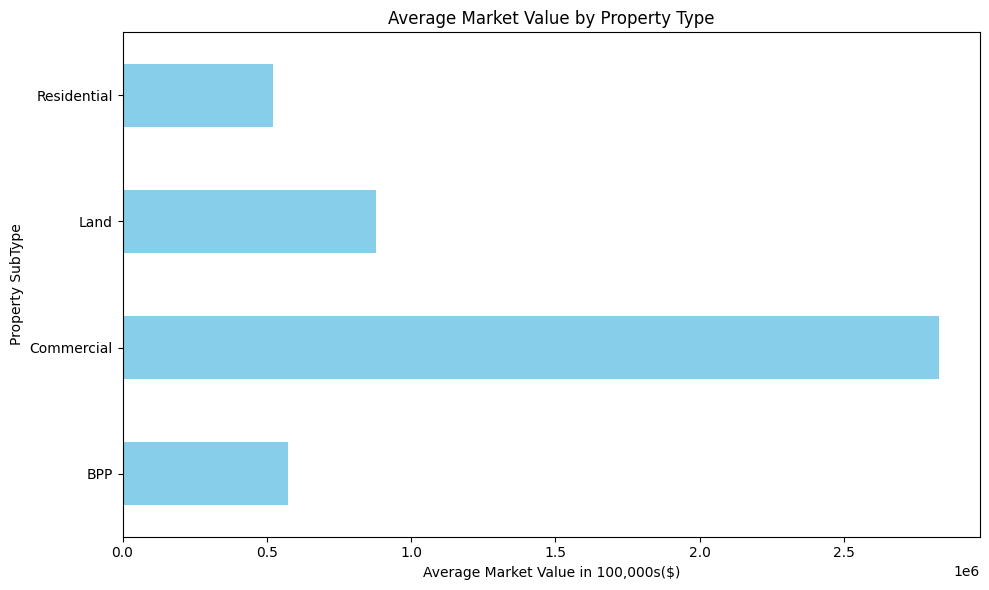

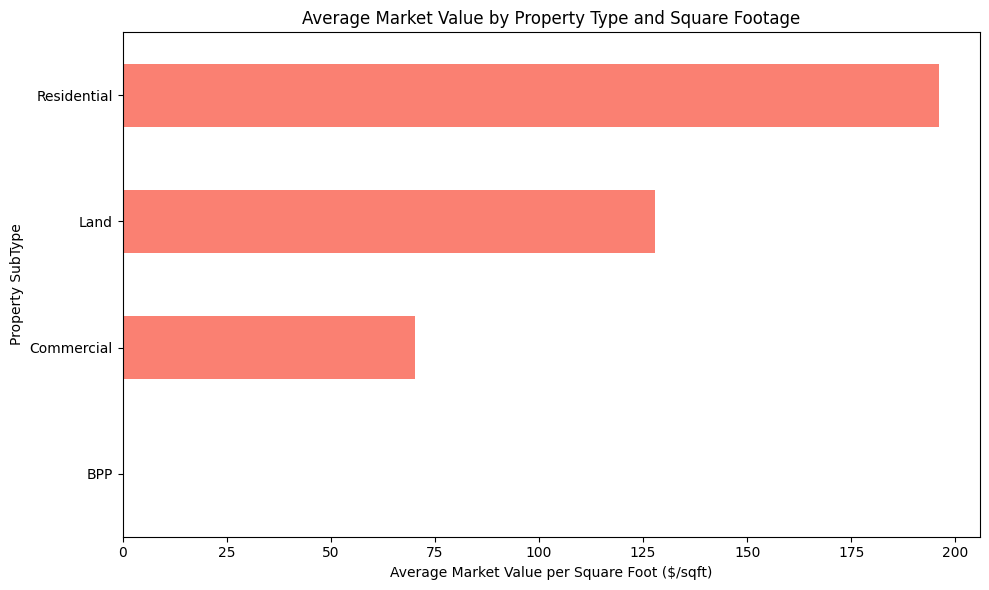

In [ ]:
# Framework step 1: visualize market value across property types
market_value = df.groupby('propSubType')['currValMarket'].mean()
market_value_sqft = df.groupby('propSubType')['currValMarket'].mean() / df.groupby('propSubType')['imprvMainArea'].mean()

# drop 'Unknown' property type
market_value = market_value.drop('Unknown', errors='ignore')
market_value_sqft = market_value_sqft.drop('Unknown', errors='ignore')

# plot
market_value.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Average Market Value by Property Type')
plt.xlabel('Average Market Value in 100,000s($)')
plt.ylabel('Property SubType')
plt.tight_layout()
plt.show()


market_value_sqft.plot(kind='barh', figsize=(10, 6), color='salmon')
plt.title('Average Market Value by Property Type and Square Footage')
plt.xlabel('Average Market Value per Square Foot ($/sqft)')
plt.ylabel('Property SubType')
plt.tight_layout()
plt.show()


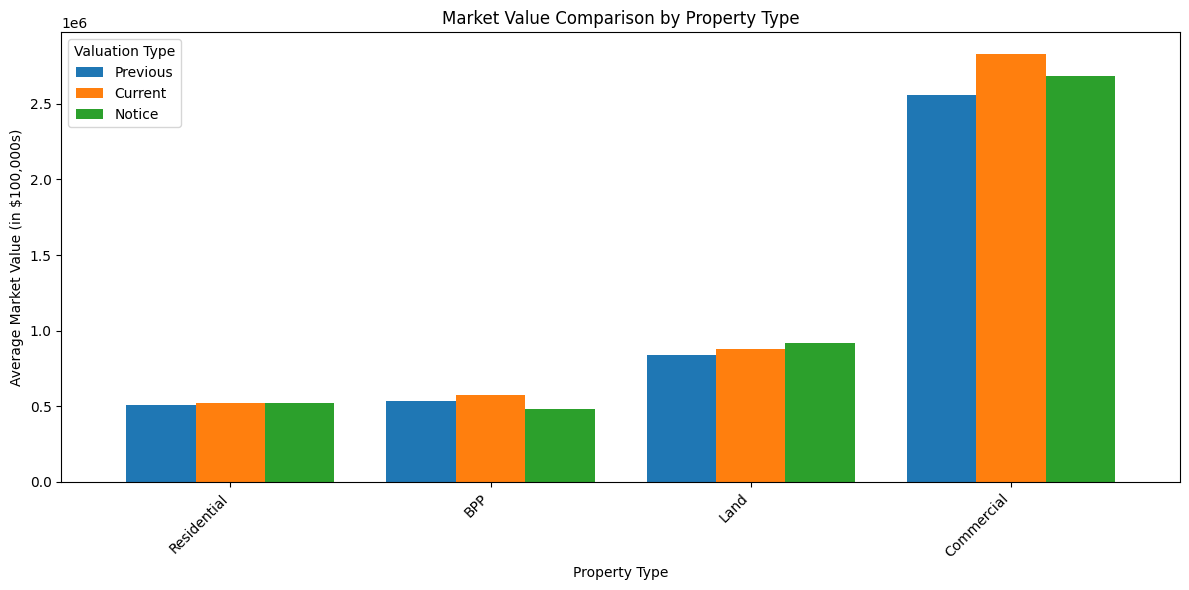

In [ ]:
# Framework step 3: compare previous, current, and notice market value across property types

# group means by property type
pre = df.groupby('propSubType')['prevValMarket'].mean()
curr = df.groupby('propSubType')['currValMarket'].mean()
notice = df.groupby('propSubType')['noticeValMarket'].mean()

# create dataframe
market_comparison = pd.DataFrame({
    'Previous': pre,
    'Current': curr,
    'Notice': notice
})

# sort by current value (as of 2024)
market_comparison = market_comparison.sort_values(by='Current')

# drop 'Unknown' property type if present
market_comparison = market_comparison.drop('Unknown', errors='ignore')

# grouped bar chart
market_comparison.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Market Value Comparison by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Market Value (in $100,000s)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Valuation Type')
plt.tight_layout()
plt.show()

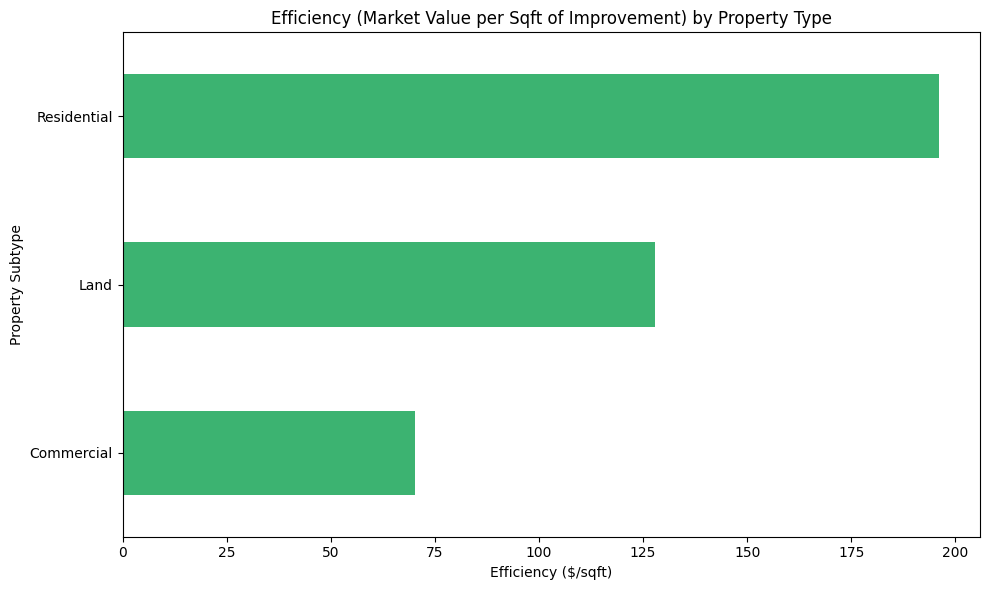

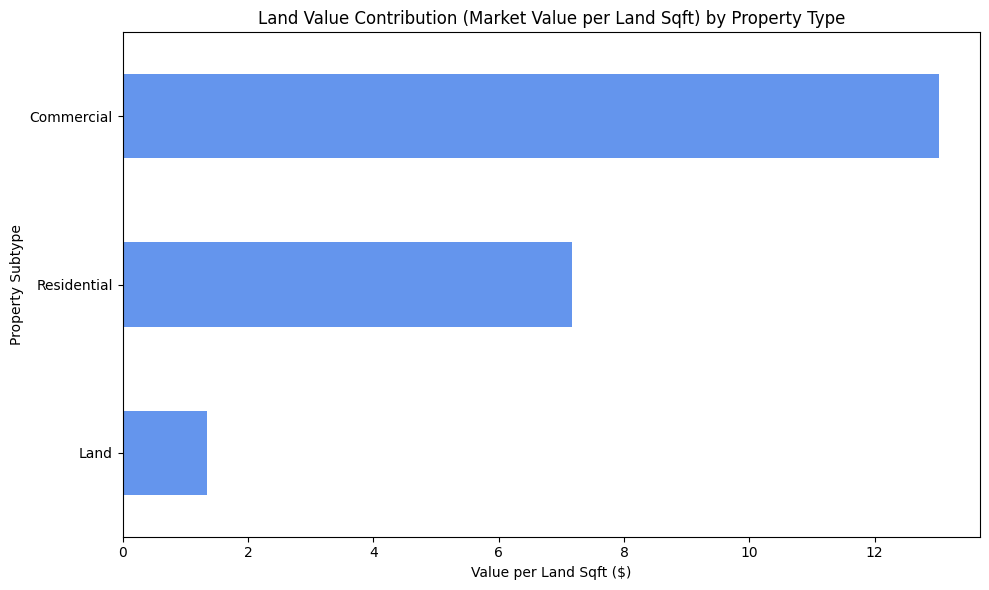

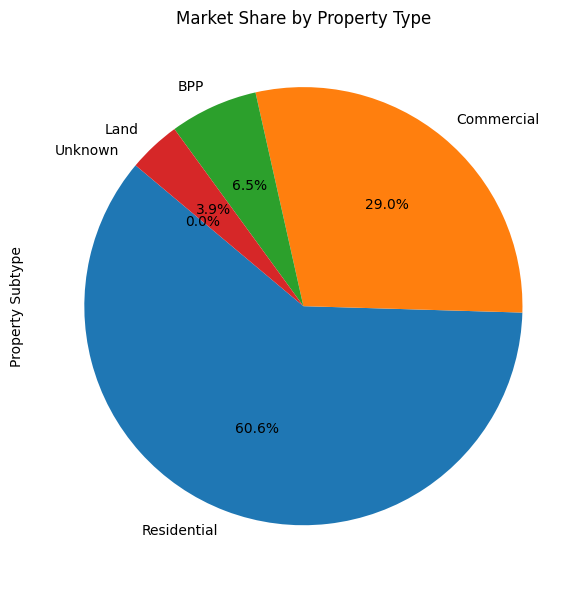

In [ ]:
# Frameowrk step 6: Capture Analysis

# efficiency, land value contribution, and market share calculations
efficiency = df.groupby('propSubType')['currValMarket'].mean() / df.groupby('propSubType')['imprvMainArea'].mean()
land_value_contribution = df.groupby('propSubType')['currValMarket'].mean() / df.groupby('propSubType')['landSizeSqft'].mean()
market_share = df.groupby('propSubType')['currValMarket'].sum() / df.groupby('propSubType')['currValMarket'].sum().sum() * 100

# drop 'Unknown' and 'BPP' from series
exclude = ['Unknown', 'BPP']
efficiency = efficiency.drop(exclude, errors='ignore')
land_value_contribution = land_value_contribution.drop(exclude, errors='ignore')

# horizontal bar chart for efficiency
efficiency.sort_values().plot(kind='barh', figsize=(10, 6), color='mediumseagreen')
plt.title('Efficiency (Market Value per Sqft of Improvement) by Property Type')
plt.xlabel('Efficiency ($/sqft)')
plt.ylabel('Property Subtype')
plt.tight_layout()
plt.show()

# horizontal bar chart for land contribution
land_value_contribution.sort_values().plot(kind='barh', figsize=(10, 6), color='cornflowerblue')
plt.title('Land Value Contribution (Market Value per Land Sqft) by Property Type')
plt.xlabel('Value per Land Sqft ($)')
plt.ylabel('Property Subtype')
plt.tight_layout()
plt.show()

# pie chart for market value share
market_share.sort_values(ascending=False).plot(
    kind='pie', figsize=(6, 6), autopct='%1.1f%%', startangle=140)
plt.title('Market Share by Property Type')
plt.ylabel('Property Subtype')
plt.tight_layout()
plt.show()

##RQ 2: What is the change in market value in the most populous cities over time?


/tmp/ipython-input-38-1960280499.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


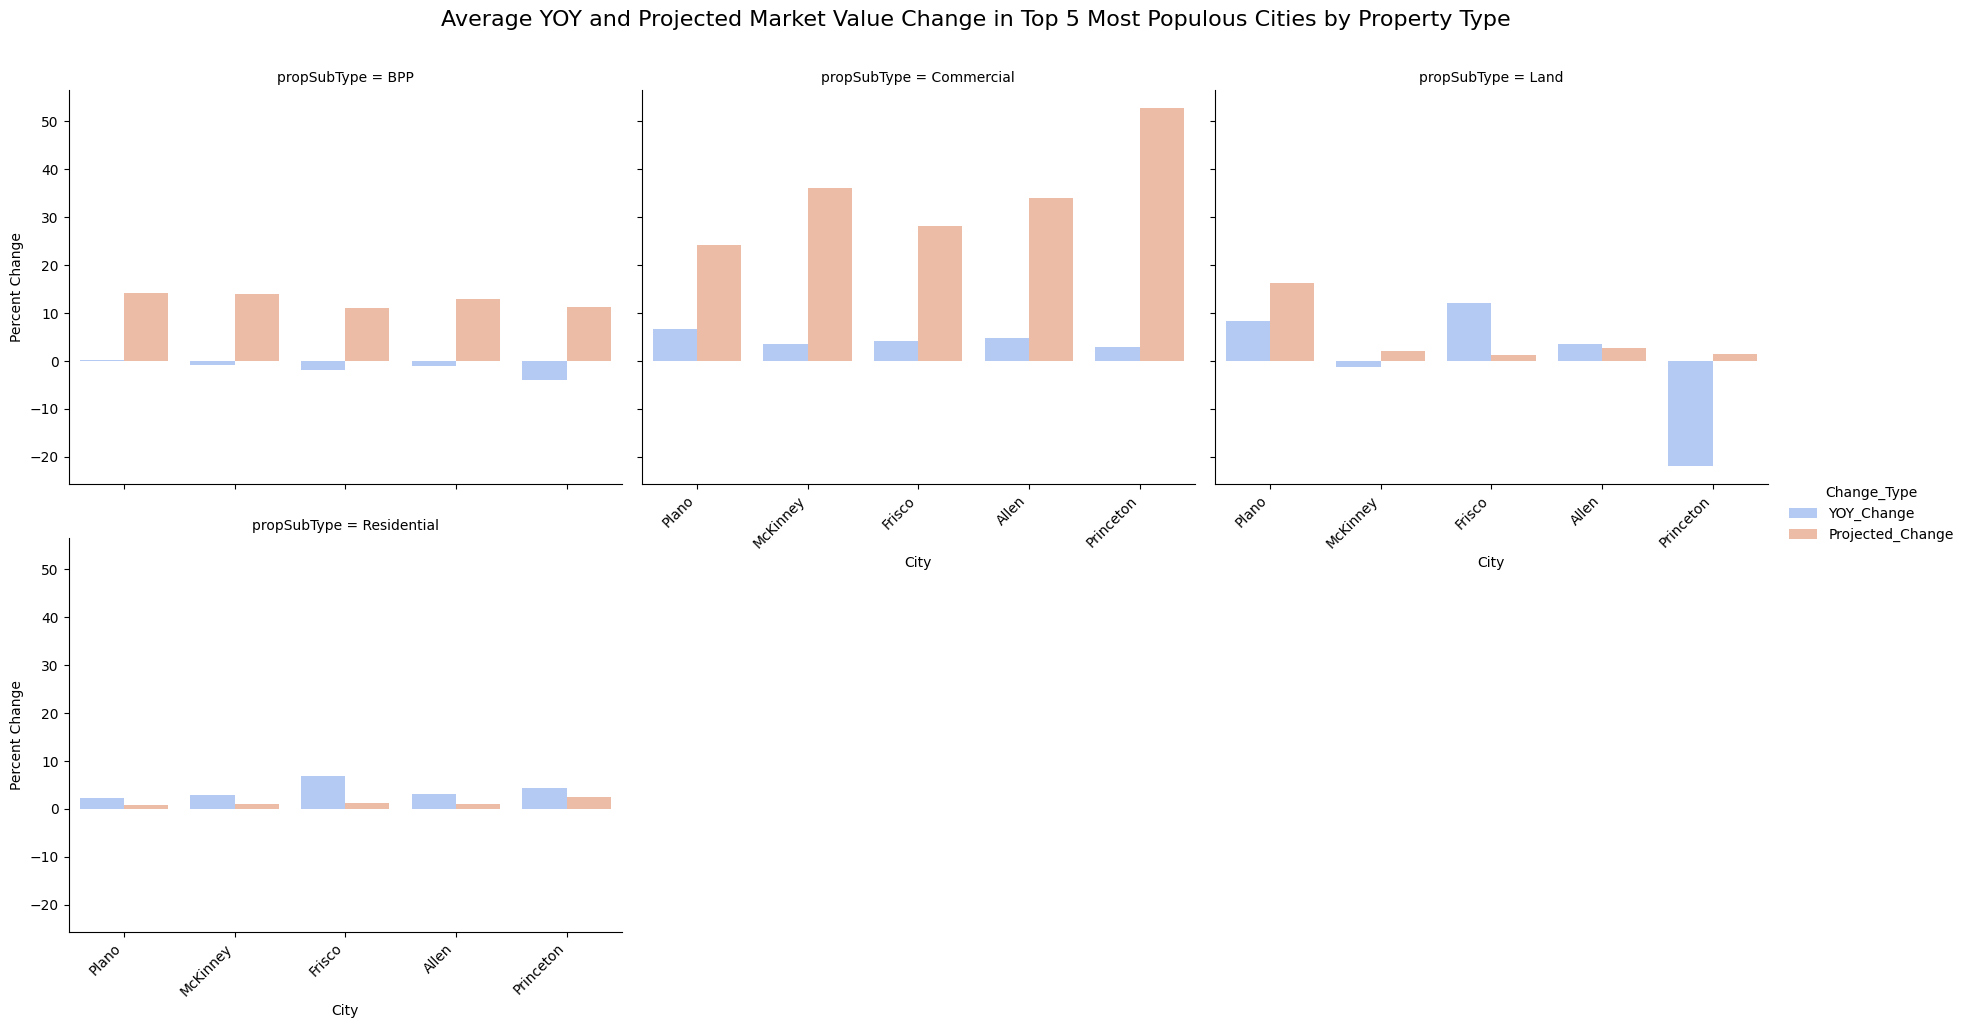

In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# SQL query
conn = sqlite3.connect(':memory:')
df.to_sql('properties', conn, index=False, if_exists='replace')

# get top 5 cities
query = '''
SELECT situsCity, COUNT(*) AS num_properties
FROM properties
WHERE situsCity IS NOT NULL
GROUP BY situsCity
ORDER BY num_properties DESC
LIMIT 5
'''
top_cities_df = pd.read_sql(query, conn)
top_cities_list = top_cities_df['situsCity'].tolist()

# filter
df_top = df[df['situsCity'].isin(top_cities_list)].copy()

# clean and Calculate Changes
df_top = df_top[(df_top['prevValMarket'] != 0) & (df_top['currValMarket'] != 0)]
df_top = df_top.dropna(subset=['prevValMarket', 'currValMarket', 'noticeValMarket'])

df_top['YOY_Change'] = ((df_top['currValMarket'] - df_top['prevValMarket']) / df_top['prevValMarket']) * 100
df_top['Projected_Change'] = ((df_top['noticeValMarket'] - df_top['currValMarket']) / df_top['currValMarket']) * 100

# clip extreme values for cleaner visuals
df_top['YOY_Change'] = df_top['YOY_Change'].clip(-50, 100)
df_top['Projected_Change'] = df_top['Projected_Change'].clip(-50, 100)

# group by city and property subtype
avg_changes = df_top.groupby(['situsCity', 'propSubType'])[['YOY_Change', 'Projected_Change']].mean().reset_index()

# melt for Seaborn
melted = avg_changes.melt(id_vars=['situsCity', 'propSubType'],
                          value_vars=['YOY_Change', 'Projected_Change'],
                          var_name='Change_Type', value_name='Percent_Change')

# drop missing cities and sort x-axis
melted = melted.dropna(subset=['situsCity', 'Percent_Change'])
melted['situsCity'] = melted['situsCity'].astype(str)
custom_labels = ['Plano', 'McKinney', 'Frisco', 'Allen', 'Princeton']

# plot
g = sns.catplot(
    data=melted,
    kind='bar',
    x='situsCity',
    y='Percent_Change',
    hue='Change_Type',
    col='propSubType',
    col_wrap=3,
    palette='coolwarm',
    height=5,
    aspect=1.2,
    ci=None,
    order=city_order
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Average YOY and Projected Market Value Change in Top 5 Most Populous Cities by Property Type", fontsize=16)
for ax in g.axes.flat:
    ax.set_xticks(range(len(custom_labels)))  # Set tick positions
    ax.set_xticklabels(custom_labels, rotation=45, ha='right')
g.set_axis_labels("City", "Percent Change")



Most populous in data: Plano, McKinney, Frisco, Allen, Princeton

In [ ]:
print(melted[['situsCity', 'propSubType', 'Percent_Change']].dropna().head(10))


  situsCity  propSubType  Percent_Change
0     ALLEN          BPP       -1.129760
1     ALLEN   Commercial        4.774581
2     ALLEN         Land        3.524635
3     ALLEN  Residential        3.051108
4    FRISCO          BPP       -1.955523
5    FRISCO   Commercial        4.211978
6    FRISCO         Land       12.056535
7    FRISCO  Residential        6.891720
8  MCKINNEY          BPP       -0.762102
9  MCKINNEY   Commercial        3.539735


##RQ 3: How accurately can market value be predicted based on structural attributes, ownership, and location?


In [ ]:
# test highest rated algorithms on the Collin County data, compare metrics to choose algorithm for Collin. WHICH METRICS WILL YOU CHOOSE
# which structural and locational attributes most contribute to property value


# structural attributes: imprvYearBuilt, imprvClassCd, imprvMainArea, imprvUnits, imprvPoolFlag, imprvCategoryCodes, landTypeCode, landSizeAcres, landSizeSqft, landAgAcres, landCategoryCodes, propType, propSubType, propYear
# ownership attributes: ownerID, ownerName, ownerNameAddtl, ownerAddrLine1, ownerAddrLine2, ownerAddrCity, ownerAddrState, ownerAddrZip, ownerAddrCountry, taxAgentID, taxAgentName, dbaName, comPropFlag, udiPropFlag, udiGroupID, udiInterestPct, commonInterestPct
# locational attributes: geoID, nbhdCode, marketAreaCode, mapID, situsBldgNum, situsStreetPrefix, situsStreetName, situsStreetSuffix, situsUnit, situsCity, situsZip, situsConcat, situsConcatShort, entityCityCode, entitySchoolCode, entityMUD, entityTIF, entitySBCL


###XGBoost

In [ ]:
# select features and target
X = df.drop(columns=['currValMarket'])
y = df['currValMarket']

# encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LASSO with cross-validation
lasso = LassoCV(cv=5).fit(X_scaled, y)

# get selected features
selected_features = X.columns[lasso.coef_ != 0]
print("Selected Features via LASSO:")
print(selected_features)



Note on selected features: which structural and locational attributes were chosen?

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Collin_CAD_Appraisal_Data_-_2024_20250717.csv', low_memory=False)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# select features and target
X = df.drop(columns=['currValMarket', 'noticeValMarket'])  # or whatever your target is
y = df['currValMarket']

# encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LASSO with cross-validation
lasso = LassoCV(cv=5).fit(X_scaled, y)

# get selected features
selected_features = X.columns[lasso.coef_ != 0]
print("Selected Features via LASSO:")
print(selected_features)

### ANN

In [ ]:
# MLP with Bayesian Regularization and backpropogation, 2 hidden layers with per Štubňová et al. (2020)
import torch
import torch.nn as nn
import torch.optim as optim

# --- Prepare data ---
X = df.drop(columns=['currValMarket', 'noticeValMarket']) #DROP TARGET!!
y = df['currValMarket']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# --- Define MLP Model ---
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.hidden1 = nn.Linear(input_dim, 64)
        self.hidden2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        return x

# Instantiate model
model = MLP(input_dim=X_train.shape[1])

# --- Define Loss and Optimizer with weight decay (L2 regularization) ---
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # weight_decay ~ Bayesian Regularization

# --- Training Loop ---
epochs = 1000
best_loss = float('inf')
patience = 50
trigger_times = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    # Early stopping check on training loss
    if loss.item() < best_loss:
        best_loss = loss.item()
        trigger_times = 0
        best_model_state = model.state_dict()
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Load best model weights
model.load_state_dict(best_model_state)

# --- Evaluate on test set ---
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
accuracy = accuracy_score(y_test.numpy(), y_pred.round())
rmse = np.sqrt(mean_squared_error(y_test.numpy(), y_pred))
r2 = r2_score(y_test.numpy(), y_pred)

print(f"Test Accuracy: {accuracy:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R2: {r2:.3f}")

##RQ 4: How do amenities and non-structural attributes impact the market value of residential properties in Collin County?


In [ ]:
#which non-structural attributes contribute most to residential prop value
#compare to literature
#OLS (Nicholls and Crompton, 2005)

1. filter data for residential property, drop non predictive columns, and apply PCA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# filter for residential property only
residential_df = df[df['propSubType'] == 'Residential'].copy()

# drop target and non-numeric columns
X = residential_df.drop(columns=['noticeValMarket'])
X = X.select_dtypes(include='number')

# define ID-like columns
non_predictive_cols = [
    'propID', 'geoID', 'mapID', 'udiGroupID', 'propYear',
    'legalAbsSubLot', 'legalDescription', 'dbaName',
    'propSplitFromPID', 'ownerID', 'ownerName', 'ownerNameAddtl',
    'situsConcat', 'situsConcatShort', 'taxAgentID', 'taxAgentName',
    'deedNum', 'deedBook', 'deedPage', 'noticeDate', 'dataDate'
]

# define categorical columns
categorical_cols = [
    'propType', 'propSubType', 'propCategoryCode', 'propUseCode',
    'nbhdCode', 'marketAreaCode', 'legalAbsSubCode',
    'legalAbsSubName', 'legalAbsSubBlock', 'imprvClassCd',
    'landTypeCode', 'landCategoryCodes', 'exemptCodes',
    'entitySchoolCode', 'entityCityCode', 'entityMUD',
    'entityTIF', 'entitySBCL', 'situsCity', 'situsZip',
    'deedTypeCd', 'propStatus', 'protestCode', 'exemptHmstdFlag',
    'comPropFlag', 'udiPropFlag', 'imprvPoolFlag'
]

# define numeric columns to keep
numeric_cols = [
    'udiInterestPct', 'commonInterestPct', 'ecoGroupGBA', 'ecoGroupNRA',
    'currValYear', 'currValImprv', 'currValLand', 'currValAgLoss',
    'currValAppraised', 'currValHSCapLoss', 'currValNHSCapLoss', 'currValAssessed',
    'prevValYear', 'prevValImprv', 'prevValLand', 'prevValMarket', 'prevValAgLoss',
    'prevValAppraised', 'prevValHSCapLoss', 'prevValNHSCapLoss', 'prevValAssessed',
    'noticeYear', 'noticeValImprv', 'noticeValLand', 'noticeValAgLoss',
    'noticeValAppraised', 'noticeValHSCapLoss', 'noticeValNHSCapLoss', 'noticeValAssessed',
    'landSizeAcres', 'landSizeSqft', 'landAgAcres', 'imprvYearBuilt',
    'imprvMainArea', 'imprvUnits'
]

# subset and prepare the data
df_model = df.drop(columns=non_predictive_cols, errors='ignore')

# extract and encode categorical features
X_cat = pd.get_dummies(df_model[categorical_cols], drop_first=True)

# extract numeric features
X_num = df_model[numeric_cols]

# combine all predictors
X = pd.concat([X_num, X_cat], axis=1)

# handle missing values (median imputation)
X = X.fillna(X.median(numeric_only=True))

# standardize (normalize)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# plot Cumulative Explained Variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components (Residential Only)')
plt.grid(True)
plt.show()


In [71]:
pca = PCA(n_components=0.95)
X_selected = pca.fit_transform(X_scaled)

print(f"Selected {X_selected.shape[1]} principal components.")

Selected 1 principal components.


2. Select components to retain variance

In [65]:
# cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# find number of components to retain 95% variance
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to retain 95% variance: {n_components}")


Number of components to retain 95% variance: 6


3. Redo PCA with selected components

In [66]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# create df for selected components
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])


4. Linear regression on principal components

In [67]:
import statsmodels.api as sm

# create DataFrame for PCA components
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# target variable (filtered to residential earlier)
y = residential_df['noticeValMarket']

# reset index of y to align with X_pca_df
y = y.reset_index(drop=True)

# add constant for intercept
X_pca_df_sm = sm.add_constant(X_pca_df)

# fit OLS model
model = sm.OLS(y, X_pca_df_sm).fit()

# results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        noticeValMarket   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 6.450e+05
Date:                Mon, 21 Jul 2025   Prob (F-statistic):               0.00
Time:                        02:41:47   Log-Likelihood:            -4.8817e+06
No. Observations:              371950   AIC:                         9.763e+06
Df Residuals:                  371943   BIC:                         9.764e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.242e+05    198.835   2636.248      0.0

In [69]:
# top components
n_components = 5
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# rename more descriptively
component_names = [f'Residential_PC{i+1}' for i in range(n_components)]

# create df
X_pca_df = pd.DataFrame(X_pca, columns=component_names)


top_components = pd.DataFrame(pca.components_.T,
                        index=X.columns,
                        columns=component_names)
print(top_components.head())


                  Residential_PC1  Residential_PC2  Residential_PC3  \
propYear                -0.000000        -0.000000        -0.000000   
propID                   0.680671        -0.194559        -0.017505   
udiGroupID               0.124786         0.199197         0.405733   
propSplitFromPID         0.025041         0.270596         0.804338   
ownerID                  0.700537        -0.078750         0.007573   

                  Residential_PC4  Residential_PC5  
propYear                 0.000000        -0.000000  
propID                  -0.080135         0.162321  
udiGroupID               0.852868        -0.210060  
propSplitFromPID        -0.497319        -0.169884  
ownerID                 -0.037039        -0.103920  


###Evaluation

In [ ]:
#Ridge regularization
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.1, 1.0, 10.0])
ridge.fit(X_train_pca, y_train)
print("Ridge R²:", ridge.score(X_test_pca, y_test))
